In [1]:
# Searching for STIX Quick-Look(ql) X-ray data (LOW Resolution data)

from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient  # This registers the STIX client with Fido

start_time = "2024-05-14T04:00:00"
end_time = "2024-05-14T06:00:00"

ql_query = Fido.search(a.Time(start_time, end_time), 
                       a.Instrument.stix,
                       a.stix.DataProduct.ql_lightcurve)
ql_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str2,str13,str3,str1
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-


In [2]:
# Downloading the datasets

ql_files = Fido.fetch(ql_query)
print("Downloaded STIX Files:", ql_files)
ql_files 

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Downloaded STIX Files: ['/home/jashhwanth/sunpy/data/solo_L1_stix-ql-lightcurve_20240514_V02.fits']


['/home/jashhwanth/sunpy/data/solo_L1_stix-ql-lightcurve_20240514_V02.fits']

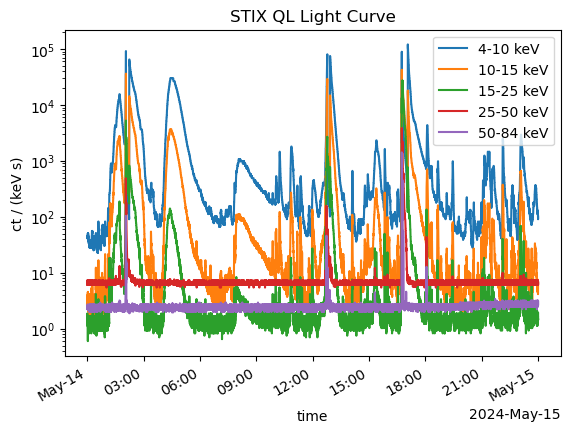

                         control_index  timedel  triggers  triggers_comp_err  \
time                                                                           
2024-05-14 00:00:02.076              0    400.0      3455          73.901962   
2024-05-14 00:00:06.076              0    400.0      3967          73.901962   
2024-05-14 00:00:10.076              0    400.0      3711          73.901962   
2024-05-14 00:00:14.076              0    400.0      3455          73.901962   
2024-05-14 00:00:18.076              0    400.0      3455          73.901962   

                         rcr   4-10 keV  10-15 keV  15-25 keV  25-50 keV  \
time                                                                       
2024-05-14 00:00:02.076    0  45.319068   3.051845   1.525923   6.714059   
2024-05-14 00:00:06.076    0  45.323131   3.752605   1.325920   7.355106   
2024-05-14 00:00:10.076    0  45.321099   3.752437   1.225796   6.714360   
2024-05-14 00:00:14.076    0  45.319068   3.352027   1.3258

In [3]:
# Loading STIX X-ray time series

from datetime import datetime
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook # This registers the STIX timeseries with sunpy
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, ScalarFormatter


ql_lightcurves = TimeSeries(ql_files)

ql_lightcurves.peek()

print(ql_lightcurves.to_dataframe().head())

print("Time Range:", ql_lightcurves.time_range)  # Check the actual available time range

print(ql_lightcurves.columns) 

['2024-05-14T00:00:02.076000000' '2024-05-14T00:00:06.076000000'
 '2024-05-14T00:00:10.076000000' ... '2024-05-14T23:59:49.876000000'
 '2024-05-14T23:59:53.876000000' '2024-05-14T23:59:57.876000000'] time
2024-05-14 00:00:02.076    2.464726
2024-05-14 00:00:06.076    2.464947
2024-05-14 00:00:10.076    2.229389
2024-05-14 00:00:14.076    2.464726
2024-05-14 00:00:18.076    2.229289
Name: 50-84 keV, dtype: float64


/tmp/ipykernel_261876/1808701701.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


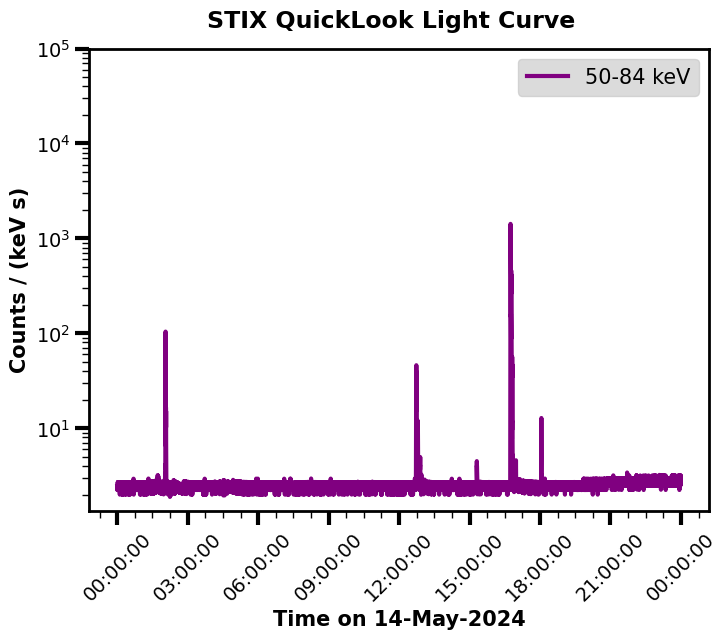

In [5]:
# Plotting peaks of energy curve 50-84 keV

from scipy.signal import find_peaks
import matplotlib.dates as mdates



selected_curve = ql_lightcurves.to_dataframe()['50-84 keV']

time_array = ql_lightcurves.to_dataframe().index.to_numpy()

print(time_array, selected_curve.head())


# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(time_array, selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)



# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S')) 

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve  ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


plt.show()
# print(selected_curve.head())

/tmp/ipykernel_261876/378122576.py:32: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Duration: 150 seconds


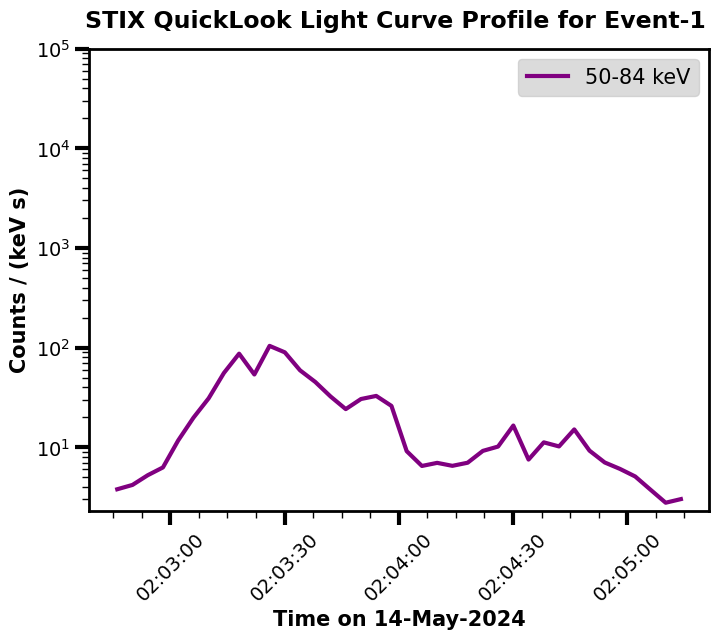

In [6]:
# Plotting Individual peaks of energy curve 50-84 keV

# Event-1

import numpy as np
import matplotlib.dates as mdates

# Define start and end times
start_time = np.datetime64("2024-05-14T02:02:45")
end_time = np.datetime64("2024-05-14T02:05:15")

# Applying boolean mask to filter time values within the range
mask = (time_array >= start_time) & (time_array <= end_time)

# Selecting the filtered times
filtered_time_array = time_array[mask]

#print("Filtered Time Array:", filtered_time_array)


filtered_selected_curve = selected_curve[mask]  # Assuming selected_curve is a 1D NumPy array

#print("Filtered Data:", filtered_selected_curve)



# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(filtered_time_array, filtered_selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S')) 

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve Profile for Event-1 ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


# Calculate duration
duration = end_time - start_time
print("Duration:", duration) 

/tmp/ipykernel_261876/2566901844.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Duration: 420 seconds


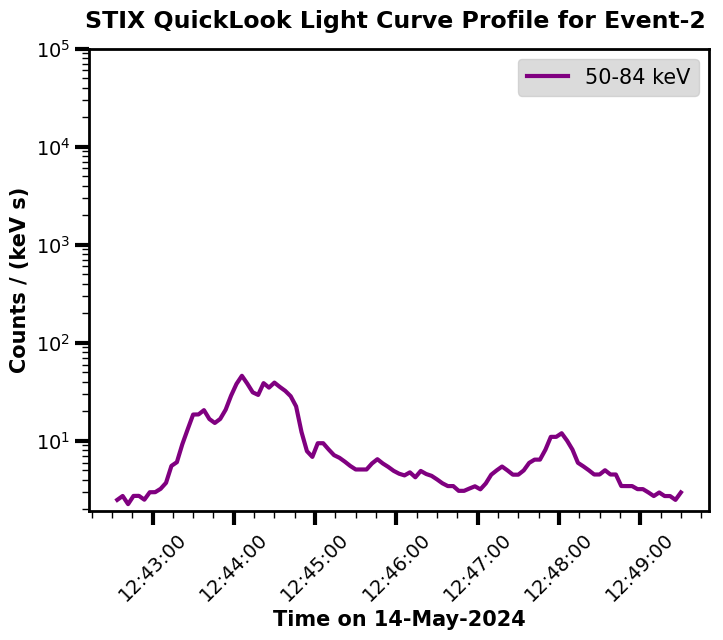

In [11]:
# Event-2

import numpy as np
import matplotlib.dates as mdates

# Define start and end times
start_time = np.datetime64("2024-05-14T12:42:30")
end_time = np.datetime64("2024-05-14T12:49:30")

# Applying boolean mask to filter time values within the range
mask = (time_array >= start_time) & (time_array <= end_time)

# Selecting the filtered times
filtered_time_array = time_array[mask]

#print("Filtered Time Array:", filtered_time_array)


filtered_selected_curve = selected_curve[mask]  # Assuming selected_curve is a 1D NumPy array

#print("Filtered Data:", filtered_selected_curve)



# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(filtered_time_array, filtered_selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve Profile for Event-2 ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


# Calculate duration
duration = end_time - start_time
print("Duration:", duration) 

/tmp/ipykernel_261876/2143844559.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Duration: 90 seconds


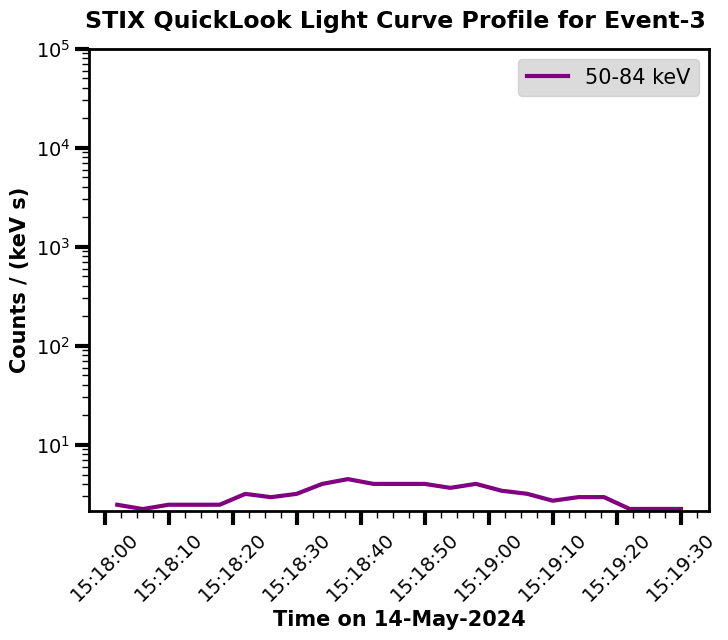

In [8]:
# Event-3

import numpy as np
import matplotlib.dates as mdates

# Define start and end times
start_time = np.datetime64("2024-05-14T15:18:00")
end_time = np.datetime64("2024-05-14T15:19:30")

# Applying boolean mask to filter time values within the range
mask = (time_array >= start_time) & (time_array <= end_time)

# Selecting the filtered times
filtered_time_array = time_array[mask]

#print("Filtered Time Array:", filtered_time_array)


filtered_selected_curve = selected_curve[mask]  # Assuming selected_curve is a 1D NumPy array

#print("Filtered Data:", filtered_selected_curve)



# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(filtered_time_array, filtered_selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve Profile for Event-3 ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


# Calculate duration
duration = end_time - start_time
print("Duration:", duration) 


/tmp/ipykernel_261876/3694791316.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Duration: 480 seconds


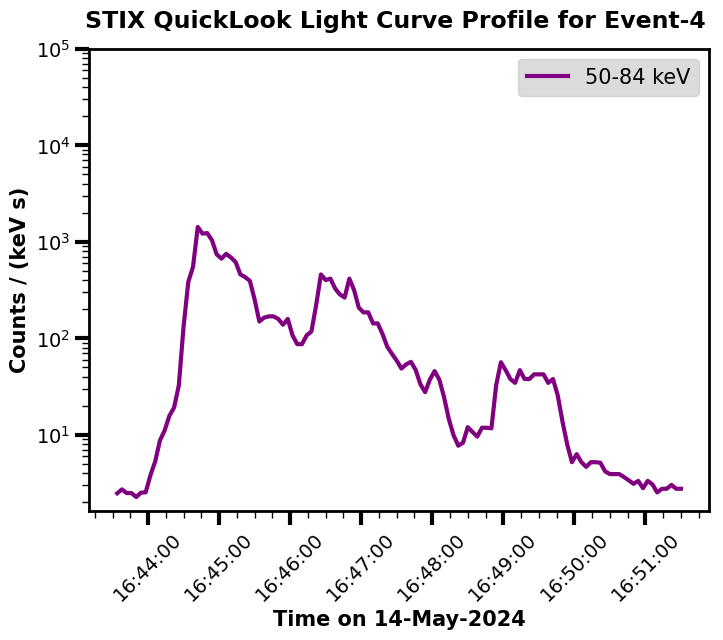

In [9]:
# Event-4

import numpy as np

# Define start and end times
start_time = np.datetime64("2024-05-14T16:43:30")
end_time = np.datetime64("2024-05-14T16:51:30")

# Applying boolean mask to filter time values within the range
mask = (time_array >= start_time) & (time_array <= end_time)

# Selecting the filtered times
filtered_time_array = time_array[mask]

#print("Filtered Time Array:", filtered_time_array)


filtered_selected_curve = selected_curve[mask]  # Assuming selected_curve is a 1D NumPy array

#print("Filtered Data:", filtered_selected_curve)



# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(filtered_time_array, filtered_selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve Profile for Event-4 ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


# Calculate duration
duration = end_time - start_time
print("Duration:", duration) 

/tmp/ipykernel_261876/3962027827.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Duration: 50 seconds


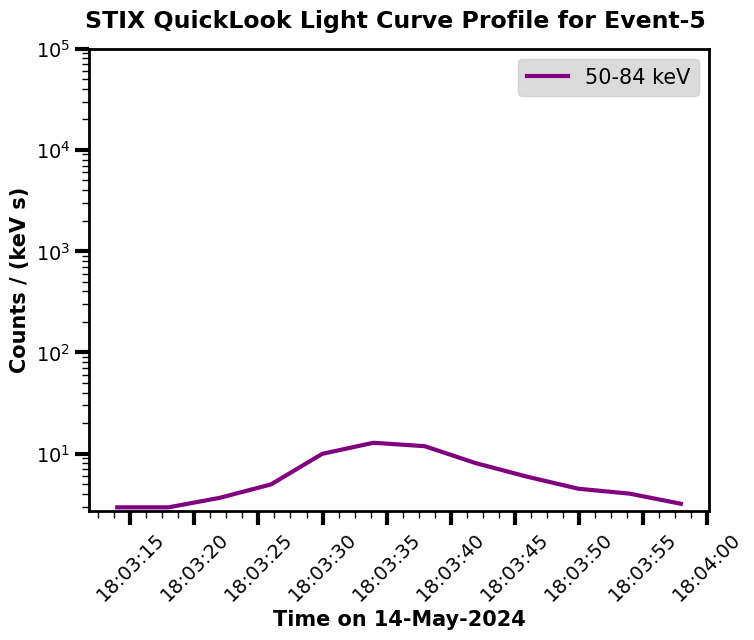

In [10]:
# Event-5

import numpy as np

# Define start and end times
start_time = np.datetime64("2024-05-14T18:03:10")
end_time = np.datetime64("2024-05-14T18:04:00")

# Applying boolean mask to filter time values within the range
mask = (time_array >= start_time) & (time_array <= end_time)

# Selecting the filtered times
filtered_time_array = time_array[mask]

#print("Filtered Time Array:", filtered_time_array)


filtered_selected_curve = selected_curve[mask]  # Assuming selected_curve is a 1D NumPy array

#print("Filtered Data:", filtered_selected_curve)



# PLOTTING 

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(filtered_time_array, filtered_selected_curve, color='purple',linewidth=3, label="50-84 keV")
ax.set_yscale("log")
ax.set_ylim(0, 100000)

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks


ax.set_xlabel("Time on 14-May-2024", fontsize=15, fontweight='bold')
ax.set_ylabel("Counts / (keV s)", fontsize=15, fontweight='bold')
ax.set_title("STIX QuickLook Light Curve Profile for Event-5 ",fontsize=17, fontweight='bold', pad=15)
plt.xticks(rotation=45)


ax.legend(loc="upper right", fontsize=15, frameon=True, facecolor="lightgray")  # Show legend in subplot


# Calculate duration
duration = end_time - start_time
print("Duration:", duration) 